# Deep Learning - Exercise 6

The aim of the lecture is to learn how to use recurrent neural networks (RNN) for text data analysis, specifically focusing on sentiment analysis tasks using Twitter data.

**Core Concepts**
* 🧠 Recurrent neural networks for sequence processing
* 📝 Sentiment analysis of textual data
* 🐦 Twitter dataset utilization
* 🔤 GloVe embeddings for word representation
* 📊 Text classification by sentiment

You can download the dataset from [this link](https://github.com/MohamedAfham/Twitter-Sentiment-Analysis-Supervised-Learning/tree/master/Data)

[Open in Google colab](https://colab.research.google.com/github/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_06.ipynb)
[Download from Github](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_06.ipynb)

##### Remember to set **GPU** runtime in Colab!

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np 
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow import string as tf_string
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import LSTM, GRU, Bidirectional

from sklearn.model_selection import train_test_split # 
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import normalize
import scipy
import itertools

tf.version.VERSION

'2.19.0'

# 📒 We will work with LSTM/GRU layers
* 🔎Do you know anything abour RNN in general?
    * How are they different from FCNN?

![Meme02](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_06_meme_02.png?raw=true)

* How is pure RNN and LSTM/GRU layer different?
    * 🔎 What issue of RNN do they address?
* Can you imagine some use-cases for RNN?
    * Can you imagine some limits of ML/DL solutions in the usecases as well?

## 🔎 We have some new packages today 🔎
* Below is a short description of them, check out the URLs for more details and API 

### 📌 NLTK
* NLTK is a leading platform for building Python programs to work with human language data. It provides easy-to-use interfaces to over 50 corpora and lexical resources such as WordNet, along with a suite of text processing libraries for classification, tokenization, stemming, tagging, parsing, and semantic reasoning, wrappers for industrial-strength NLP libraries, and an active discussion forum.
    * https://www.nltk.org/

### 📌 TextBlob
* TextBlob is a Python (2 and 3) library for processing textual data. It provides a simple API for diving into common natural language processing (NLP) tasks such as part-of-speech tagging, noun phrase extraction, sentiment analysis, classification, translation, and more.
    * https://textblob.readthedocs.io/en/dev/

In [2]:
import unicodedata, re, string
import nltk
from textblob import TextBlob

In [3]:
def show_history(history):
    plt.figure()
    for key in history.history.keys():
        plt.plot(history.epoch, history.history[key], label=key)
    plt.legend()
    plt.tight_layout()

## Punkt Sentence Tokenizer
* 🔎 Why do we use tokenizers?
* This tokenizer divides a text into a list of sentences by using an unsupervised algorithm to build a model for abbreviation words, collocations, and words that start sentences. 
    * It must be trained on a large collection of plaintext in the target language before it can be used.

In [4]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Download the dataset

In [5]:
df = pd.read_csv('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/train_tweets.csv')

# ⚡ Let's take a look at the data

In [6]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [7]:
df.shape

(31962, 3)

<Axes: xlabel='label', ylabel='count'>

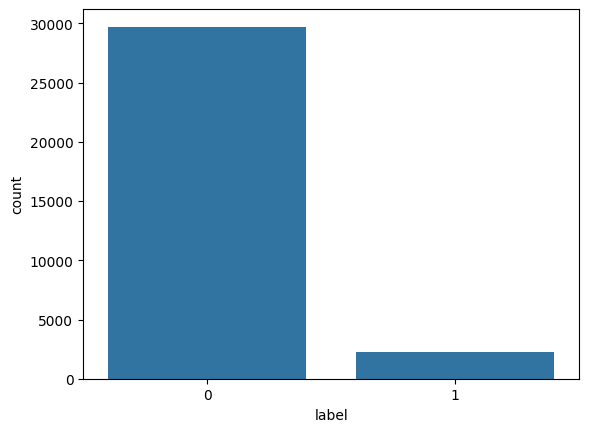

In [8]:
sns.countplot(x='label', data=df)

In [9]:
df.label.value_counts()

,count
label,
0,29720
1,2242


## We can see that the classes are highly imbalanced, because we have only 2242 negative tweets compared to positive ones number
* 🔎 What will be impacted by class imbalance?

### 💡 We can see that sentences are of similar length regardless the class

In [10]:
df['length'] = df.tweet.apply(len)

<Axes: xlabel='label', ylabel='length'>

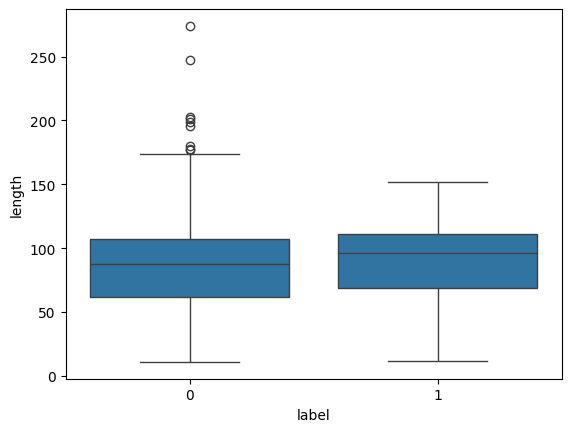

In [11]:
sns.boxplot(x='label', y='length', data = df)

## We can see that the text data are full of noise

* 💡 Social posts suffer the most from this effect
    * The text is full of hashtags, emojis, @mentions and so on
    * These parts usually don't influence the sentiment score much
* 💡 Although most advanced models usually extract even this features because e.g. emojis can help you with the sarcasm understanding

## Take a look at few examples, it will share many of these caveates which we've just discussed

In [12]:
for x in df.loc[:10, 'tweet']:
    print(x, '\n', '-'*len(x))

 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run 
 ------------------------------------------------------------------------------------------------------
@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked 
 --------------------------------------------------------------------------------------------------------------------------
  bihday your majesty 
 ---------------------
#model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦   
 --------------------------------------------------------------------------------------
 factsguide: society now    #motivation 
 ---------------------------------------
[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo   
 --------------------------------------------------------------------------------------------------------------------
 @us

# 📒 We have a few specific pre-processing techniques for the text data
* 💡 Benefits of using these techniques varies from approach to approach
    * However it is good to have at least some knowledge about them

## Stemming
* Stemming is the process of producing morphological variants of a root/base word
    * Stemming programs are commonly referred to as stemming algorithms or stemmers
* 💡 A stemming algorithm reduces the words “chocolates”, “chocolatey”, “choco” to the root word, “chocolate” and “retrieval”, “retrieved”, “retrieves” reduce to the stem “retrieve”

#### ⚡ Examples of stemming:
* chocolates, chocolatey, choco : **chocolate**
* retrieval, retrieved, retrieves : **retrieve**


## Lemmatization 
* Lemmatization is the process of grouping together the different inflected forms of a word so they can be analysed as a single item
* 💡 Lemmatization is similar to stemming but it brings context to the words
    * 💡 It links words with similar meaning to one word

#### ⚡ Examples of lemmatization:
* rocks : **rock**
* corpora : **corpus**
* better : **good**

### Both techiques can be used in the preprocessing pipeline
* You have to decide if it is beneficial to you, because this steps leads to generalization of the data by itself
    * 💡 You will definitely lose some pieces of the information!

# 📌 Embedding note
* **If you use some form of embedding like Word2Vec or Glove, it is better to skip this steps because during the embedding vocabulary building process it was skipped as well** 🙂

# You don't have to code the pre-process steps yourself 🙂
* We have already prepared the most common functions used
    * 💡 Modify function `normalize(...)` for different step combination

In [13]:
def remove_non_ascii(words):
    """Remove non-ASCII characters from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = unicodedata.normalize('NFKD', word).encode('ascii', 'ignore').decode('utf-8', 'ignore')
        new_words.append(new_word)
    return new_words

def to_lowercase(words):
    """Convert all characters to lowercase from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = word.lower()
        new_words.append(new_word)
    return new_words

def remove_punctuation(words):
    """Remove punctuation from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = re.sub(r'[^\w\s]', '', word)
        if new_word != '':
            new_words.append(new_word)
    return new_words

def remove_numbers(words):
    """Remove all interger occurrences in list of tokenized words with textual representation"""
    new_words = []
    for word in words:
        new_word = re.sub("\d+", "", word)
        if new_word != '':
            new_words.append(new_word)
    return new_words

def remove_stopwords(words):
    """Remove stop words from list of tokenized words"""
    new_words = []
    for word in words:
        if word not in stopwords.words('english'):
            new_words.append(word)
    return new_words

def stem_words(words):
    """Stem words in list of tokenized words"""
    stemmer = LancasterStemmer()
    stems = []
    for word in words:
        stem = stemmer.stem(word)
        stems.append(stem)
    return stems

def lemmatize_verbs(words):
    """Lemmatize verbs in list of tokenized words"""
    lemmatizer = WordNetLemmatizer()
    lemmas = []
    for word in words:
        lemma = lemmatizer.lemmatize(word, pos='v')
        lemmas.append(lemma)
    return lemmas

def normalize(words):
    words = remove_non_ascii(words)
    words = to_lowercase(words)
# words = remove_punctuation(words)
    words = remove_numbers(words)
#    words = remove_stopwords(words)
    return words

def form_sentence(tweet):
    tweet_blob = TextBlob(tweet)
    return tweet_blob.words

<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_847/989776649.py:30: SyntaxWarning: invalid escape sequence '\d'
  new_word = re.sub("\d+", "", word)


# First we must tokenize sentences and remove puncuation 
* We will use the `TextBlob` library

In [14]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [15]:
df['Words'] = df['tweet'].apply(form_sentence)

In [16]:
df.head()

,id,label,tweet,length,Words
0,1,0,@user when a father is dysfunctional and is s...,102,"[user, when, a, father, is, dysfunctional, and..."
1,2,0,@user @user thanks for #lyft credit i can't us...,122,"[user, user, thanks, for, lyft, credit, i, ca,..."
2,3,0,bihday your majesty,21,"[bihday, your, majesty]"
3,4,0,#model i love u take with u all the time in ...,86,"[model, i, love, u, take, with, u, all, the, t..."
4,5,0,factsguide: society now #motivation,39,"[factsguide, society, now, motivation]"


# Normalize sentences 
* We want only ascii and lowercase characters and we also want to get rid of numbers in the strings

### You can always experiments with different preprocessing steps! 🙂
* 💡 The steps choice usually depends on the dataset

In [17]:
df['Words_normalized'] = df['Words'].apply(normalize)

In [18]:
df.head()

,id,label,tweet,length,Words,Words_normalized
0,1,0,@user when a father is dysfunctional and is s...,102,"[user, when, a, father, is, dysfunctional, and...","[user, when, a, father, is, dysfunctional, and..."
1,2,0,@user @user thanks for #lyft credit i can't us...,122,"[user, user, thanks, for, lyft, credit, i, ca,...","[user, user, thanks, for, lyft, credit, i, ca,..."
2,3,0,bihday your majesty,21,"[bihday, your, majesty]","[bihday, your, majesty]"
3,4,0,#model i love u take with u all the time in ...,86,"[model, i, love, u, take, with, u, all, the, t...","[model, i, love, u, take, with, u, all, the, t..."
4,5,0,factsguide: society now #motivation,39,"[factsguide, society, now, motivation]","[factsguide, society, now, motivation]"


## Remove the 'user' word from tweets

In [19]:
df['Words_normalized_no_user'] = df['Words_normalized'].apply(lambda x: [y for y in x if 'user' not in y])

In [20]:
df.head()

,id,label,tweet,length,Words,Words_normalized,Words_normalized_no_user
0,1,0,@user when a father is dysfunctional and is s...,102,"[user, when, a, father, is, dysfunctional, and...","[user, when, a, father, is, dysfunctional, and...","[when, a, father, is, dysfunctional, and, is, ..."
1,2,0,@user @user thanks for #lyft credit i can't us...,122,"[user, user, thanks, for, lyft, credit, i, ca,...","[user, user, thanks, for, lyft, credit, i, ca,...","[thanks, for, lyft, credit, i, ca, n't, use, c..."
2,3,0,bihday your majesty,21,"[bihday, your, majesty]","[bihday, your, majesty]","[bihday, your, majesty]"
3,4,0,#model i love u take with u all the time in ...,86,"[model, i, love, u, take, with, u, all, the, t...","[model, i, love, u, take, with, u, all, the, t...","[model, i, love, u, take, with, u, all, the, t..."
4,5,0,factsguide: society now #motivation,39,"[factsguide, society, now, motivation]","[factsguide, society, now, motivation]","[factsguide, society, now, motivation]"


## 💡 We can see that no pre-processing is ideal and we have to fix some issues by ourselves
* e.g. n't splitting

In [21]:
print(df.tweet.iloc[1])
print(df.Words_normalized_no_user.iloc[1])

@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
['thanks', 'for', 'lyft', 'credit', 'i', 'ca', "n't", 'use', 'cause', 'they', 'do', "n't", 'offer', 'wheelchair', 'vans', 'in', 'pdx', 'disapointed', 'getthanked']


In [22]:
def fix_nt(words):
    st_res = []
    for i in range(0, len(words) - 1):
        if words[i+1] == "n't" or words[i+1] == "nt":
            st_res.append(words[i]+("n't"))
        else:
            if words[i] != "n't" and words[i] != "nt":
                st_res.append(words[i])
    return st_res

In [23]:
df['Words_normalized_no_user_fixed'] = df['Words_normalized_no_user'].apply(fix_nt)

## ⚡ The issue is now fixed

In [24]:
print(df.tweet.iloc[1])
print(df.Words_normalized_no_user.iloc[1])
print(df.Words_normalized_no_user_fixed.iloc[1])

@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
['thanks', 'for', 'lyft', 'credit', 'i', 'ca', "n't", 'use', 'cause', 'they', 'do', "n't", 'offer', 'wheelchair', 'vans', 'in', 'pdx', 'disapointed', 'getthanked']
['thanks', 'for', 'lyft', 'credit', 'i', "can't", 'use', 'cause', 'they', "don't", 'offer', 'wheelchair', 'vans', 'in', 'pdx', 'disapointed']


## Now we can join the text into single string again for each instance

In [25]:
df['Clean_text'] = df['Words_normalized_no_user_fixed'].apply(lambda x: " ".join(x))

In [26]:
df['Clean_text'].head()

,Clean_text
0,when a father is dysfunctional and is so selfi...
1,thanks for lyft credit i can't use cause they ...
2,bihday your
3,model i love u take with u all the time in
4,factsguide society now


# 🚀 Let's take a look at the most common words in corpus
* It is one of the usual EDA step for text data
    * ⚠ Without the preprocessing there will be a lot of so-called *stopwords*

## 🔎 Do you know what the term **stopword** mean?

## Step 1: Tokenize each string and merge the token array into one big array using `itertools.chain()`

In [27]:
all_words = list(itertools.chain(*df.Words_normalized_no_user_fixed))

In [28]:
all_words[:20]

['when',
 'a',
 'father',
 'is',
 'dysfunctional',
 'and',
 'is',
 'so',
 'selfish',
 'he',
 'drags',
 'his',
 'kids',
 'into',
 'his',
 'dysfunction',
 'thanks',
 'for',
 'lyft',
 'credit']

## Step 2: Compute frequency of every token using `nltk`

In [29]:
dist = nltk.FreqDist(all_words)

## 💡 The most common tokens are:

In [30]:
dist

FreqDist({'the': 10136, 'to': 9798, 'a': 7680, 'i': 7165, 'you': 5679, 'and': 4868, 'in': 4615, 'for': 4462, 'of': 4133, 'is': 4048, ...})

## 💡 We have 34289 unique words (tokens)

In [31]:
len(dist)

34292

## 💡 The longest tweet has 42 tokens

In [32]:
max(df.Words_normalized_no_user_fixed.apply(len))

42

# 🚀 Our dataset is ready, we can start our Deep learning experiments 
* 🔎 Can you use regular FCANN for the sentiment analysis?

![Meme01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_06_meme_01.png?raw=true)


# We will use `TextVectorization` layer for creating vector model from our text data
* For those of you who are interested in the topic there is very good [article on Medium](https://towardsdatascience.com/you-should-try-the-new-tensorflows-textvectorization-layer-a80b3c6b00ee) about the layer and its parameters
    * There is of course a [documentation page](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) about the layer as well

## 🔎 What does *text vectorization* mean in this context?
* Is it a different term from the one used in information retrieval?

## 📌 There are few important parameters:
* `emedding_dim` 
    * Dimension of embedded representation
    * This is already part of latent space, there is captured dependecy among words in these vectors, we are learning this vectors using the ANN
* `vocab_size`
    * Number of unique tokens in vocabulary
* `sequence_length`
    * Output dimension after vectorizing - words in vectorized representation are treated as independent

In [33]:
embedding_dim = 128 # Dimension of embedded representation
vocab_size = 10000 # Number of unique tokens in vocabulary
sequence_length = 30 # Output dimension after vectorizing

vect_layer = TextVectorization(max_tokens=vocab_size, output_mode='int', output_sequence_length=sequence_length)
vect_layer.adapt(df.Clean_text.values)

## We will split our dataset to train and test parts with stratification

## 🎯 COMPETITION TEST SET HERE 🎯

### COMPETITION ?!?! 🤔
* I will provide the details in the end of the lecture 🙂

In [34]:
X_train, X_test, y_train, y_test = train_test_split(df.Clean_text, df.label, test_size=0.20, random_state=13, stratify=df.label)

In [35]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=13, stratify=y_train)

In [36]:
print(X_train.shape, X_test.shape)

(23012,) (6393,)


In [37]:
print('Train')
print(y_train.value_counts())
print('Test')
print(y_test.value_counts())

Train
label
0    21397
1     1615
Name: count, dtype: int64
Test
label
0    5945
1     448
Name: count, dtype: int64


In [38]:
print('Vocabulary example: ', vect_layer.get_vocabulary()[:10])
print('Vocabulary shape: ', len(vect_layer.get_vocabulary()))

Vocabulary example:  ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('a'), np.str_('i'), np.str_('you'), np.str_('and'), np.str_('in'), np.str_('for')]
Vocabulary shape:  10000


# 🚀 Let's finally try the RNN-based model!

In [39]:
input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(vocab_size, embedding_dim)(x_v)
x = LSTM(64, activation='relu', return_sequences=True)(emb)
x = GRU(64, activation='relu', return_sequences=False)(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dense(32, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model = keras.Model(input_layer, output_layer)
model.summary()
# keras.metrics.F1Score(average='weighted',threshold=0.5, name='f1') - currently bugged
model.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.BinaryCrossentropy(), metrics=[keras.metrics.BinaryAccuracy(name='accuracy')])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,360,641 (5.19 MB)

 Trainable params: 1,360,641 (5.19 MB)

 Non-trainable params: 0 (0.00 B)

## We are using `AdamW` optimizer, which is a variant of Adam optimizer ⚙️
### Adam Optimizer 🧠

Adam (Adaptive Moment Estimation) combines two key techniques to improve neural network training:

- **Momentum** 🔄: Keeps track of previous directions, helping navigate tricky optimization landscapes like a ball rolling downhill
- **Adaptive learning rates** 📊: Adjusts the step size individually for each parameter based on its history

Adam is memory-efficient and works well for smaller networks, simple regression problems, and when working with clean datasets

**Adaptive Learning Rates in Adam: A Simple Explanation** 🧭

* Imagine you're hiking through mountains with varying terrain - steep cliffs, gentle slopes, and flat meadows 🏔️
* The "adaptive learning rates" in Adam work like an intelligent hiking assistant that helps you navigate this landscape efficiently

**How It Works** ⚙️

1. **Different Parameters Need Different Step Sizes** 📏
   - Some parameters might need big updates (steep terrain) 📈
   - Others might need tiny, careful updates (slippery slopes) 📉

2. **Adam Keeps Track of History** 📜
   - For each parameter, Adam remembers how much that parameter has changed recently
   - If a parameter has been changing a lot, Adam gives it smaller updates ⬇️
   - If a parameter has barely moved, Adam gives it larger updates ⬆️

3. **Real-World Example** 🌍
   - Parameter A has seen huge gradients (values like 10.0, 8.5, 9.2)
   - Parameter B has seen tiny gradients (values like 0.01, 0.02, 0.01)
   - With a fixed learning rate, A would move too quickly and B too slowly ⚠️
   - Adam automatically gives A smaller steps and B larger steps ✅

**Why This Matters** 💡

- **Prevents Oscillation** 🔄: Parameters that tend to bounce back and forth get smaller updates
- **Escapes Flat Regions** 🏝️: Parameters stuck in flat areas get larger updates
- **Training Stability** 🛡️: Each parameter moves at its appropriate pace
- **Faster Convergence** 🏁: The model learns more efficiently overall

This adaptive behavior is why Adam often converges faster than optimizers with fixed learning rates and requires less manual tuning.

### AdamW Optimizer 🚀

AdamW is an improved version of Adam with one crucial difference:

- **Decoupled weight decay** ⚖️: AdamW separates the weight decay (regularization) from the gradient updates, while Adam applies it as part of the gradient update process

This seemingly small change makes AdamW more effective for:
- Training large models 🏗️
- Improving generalization 🌐
- Handling complex datasets 📚

AdamW has become the default optimizer for transformer pretraining and many deep learning applications due to its consistent performance across various tasks

**Understanding Decoupled Weight Decay in AdamW** 🧩

* In traditional Adam optimization, L2 regularization (weight decay) is applied through the loss function, which means it affects the gradients before they're processed by Adam's adaptive learning rate mechanism
* This creates a problem because the adaptive nature of Adam distorts the regularization effect, especially for parameters with large historical gradients ⚠️

* AdamW solves this problem by **decoupling** weight decay from the gradient computation 🔓
* Instead of including weight decay in the loss function (which affects gradients), AdamW applies weight decay directly to the weights as a separate step in the update process

**How It Works** ⚙️

1. **Adam (with L2 regularization)** 📊: 
   - Adds the L2 penalty to the loss function: `L_new(w) = L_original(w) + λw^Tw`
   - Gradients are computed from this combined loss
   - Adam's adaptive learning rates are applied to these modified gradients
   - Problem: Parameters with large historical gradients receive less regularization ❌

2. **AdamW (with decoupled weight decay)** 🔄:
   - Computes gradients from only the original loss function
   - Applies Adam's adaptive learning rate mechanism to these gradients
   - Separately applies weight decay directly to the weights: `w = w - λw`
   - All weights are regularized equally regardless of their gradient history ✅

**Benefits of Decoupling** 🎯

1. **Better Generalization** 🌐: AdamW consistently achieves better generalization performance than Adam with L2 regularization

2. **Simplified Hyperparameter Tuning** 🎛️: The weight decay parameter becomes more independent of the learning rate, creating a more separable hyperparameter space that's easier to optimize

3. **Improved Convergence** 📈: AdamW can match or exceed the performance of SGD with momentum on tasks where Adam traditionally struggled

**Key Differences Summary** 📋

| Optimizer | Memory Usage | Key Features | Best For |
|-----------|--------------|--------------|----------|
| Adam | Medium 📊 | Momentum + adaptive learning rates | Smaller networks, prototyping 🔬 |
| AdamW | Medium 📊 | Adam + decoupled weight decay | Large models, general purpose 🚀 |

In [40]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.9279 - loss: 0.2805 - val_accuracy: 0.9320 - val_loss: 0.1902
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.9526 - loss: 0.1344 - val_accuracy: 0.9593 - val_loss: 0.1153
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.9772 - loss: 0.0744 - val_accuracy: 0.9628 - val_loss: 0.1233
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9845 - loss: 0.0504 - val_accuracy: 0.9613 - val_loss: 0.1275
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.9902 - loss: 0.0345 - val_accuracy: 0.9589 - val_loss: 0.1650


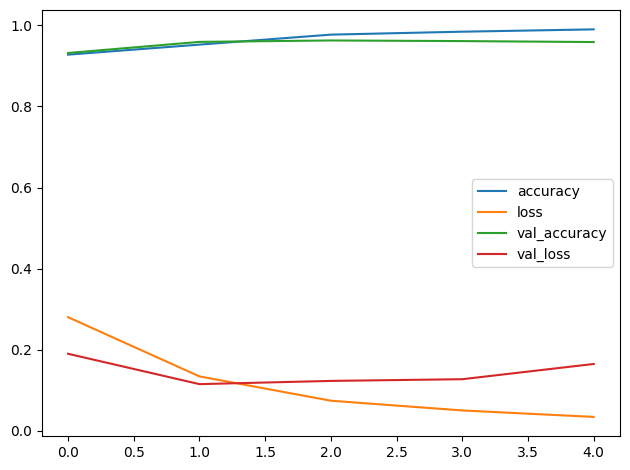

In [41]:
batch_size = 128
epochs = 5

history = model.fit(X_train.values, tf.cast(y_train.values, tf.int32), validation_data=(X_valid.values, tf.cast(y_valid.values, tf.int32)), callbacks=[model_checkpoint_callback], epochs=epochs, batch_size=batch_size)

show_history(history)

In [42]:
# Load the best setup
model.load_weights("best.weights.h5")

In [43]:
y_pred = model.predict(X_test.values).ravel()

200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


## Sigmoid function gives us real number in range <0, 1>.

In [44]:
y_pred[:10]

array([0.00835807, 0.01044352, 0.00187899, 0.02282416, 0.00030907,
       0.00069063, 0.11612029, 0.02558095, 0.08294421, 0.00559991],
      dtype=float32)

## We need to map this values to discreet classes 0 and 1

In [45]:
y_pred = [1 if x >= 0.5 else 0 for x in y_pred]

In [46]:
y_pred[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# The accuracy is not the best metric in the imbalanced situation - you already know the reason 🙂
* There are many more metrics we can use and one of the most common in this situation is the F1 Score, see [this](https://en.wikipedia.org/wiki/F-score) and [this](https://machinelearningmastery.com/classification-accuracy-is-not-enough-more-performance-measures-you-can-use/) for more info

In [47]:
accuracy_score(y_true=y_test, y_pred=y_pred)

0.9549507273580479

In [48]:
f1_score(y_true=y_test, y_pred=y_pred)

0.6240208877284595

In [49]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5945
           1       0.75      0.53      0.62       448

    accuracy                           0.95      6393
   macro avg       0.86      0.76      0.80      6393
weighted avg       0.95      0.95      0.95      6393



<Axes: >

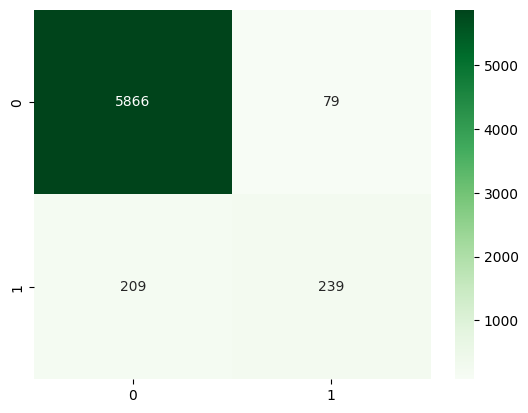

In [50]:
sns.heatmap(confusion_matrix(y_true=y_test, y_pred=y_pred), annot=True, cmap='Greens', fmt='.0f')

# Do we need to train our own embedding from scratch? 🤔
* 💡 There are multiple embeddings available online which were trained on very large corpuses e.g. Wikipedia
* Good examples are Word2Vec, Glove or FastText
    * These embeddings contains fixed length vectors for words in the vocabulary

* We will use GloVe embedding with 50 dimensional embedding vectors
    * For more details see [this](https://nlp.stanford.edu/projects/glove/)
* You can download zip with vectors from [http://nlp.stanford.edu/data/glove.6B.zip](http://nlp.stanford.edu/data/glove.6B.zip) ~ 800 MB

### 📌 Beware that the original text corpus was more general than the specific social media text data
* 💡 So if you deal with very specific domains it may be beneficial to train your own embedding or at least fine tune existing one in the end

# We need to download the embedding files
~~~
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
~~~

* 💡50 dims GLOVE is also avaiable at https://ai.vsb.cz/downloads/glove.6B.50d.txt

# First we need to load the file to memory and create embedding dictionary

In [51]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-28 06:44:11--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-28 06:44:11--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-28 06:44:11--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [52]:
!unzip -q glove.6B.zip

In [53]:
path_to_glove_file = 'glove.6B.50d.txt'

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


## 💡 This is how the embedding latent vector looks like for the word `analysis`

In [54]:
embeddings_index['analysis']

array([ 0.47168 ,  0.25095 ,  0.078363,  0.33009 ,  0.32782 ,  0.47325 ,
        0.16805 , -0.99997 ,  0.8607  ,  0.018286, -0.022716, -0.16986 ,
       -0.33896 ,  0.10096 , -0.29278 , -0.18954 ,  0.063336, -0.64536 ,
       -0.098547, -0.46883 ,  0.26338 , -0.063779,  0.51437 , -0.34739 ,
        0.26537 , -0.58654 , -1.2527  , -0.20557 , -0.31604 ,  0.59308 ,
        2.8329  , -1.2396  , -0.23409 , -1.66    ,  0.047692, -0.23141 ,
       -0.14241 ,  0.74129 ,  0.69887 ,  0.14877 ,  0.6547  , -0.29812 ,
        0.10476 ,  0.56112 , -0.015528,  0.099004,  1.3858  ,  1.8129  ,
        0.3804  ,  0.83921 ], dtype=float32)

In [55]:
embeddings_index['analysis'].shape

(50,)

# 🚀 Our goal is to use the pre-trained embedding in our model
* We need to get the vocabulary from the `TextVectorization` layer and the integer indexes

In [56]:
embedding_dim = 50 # Embedding dimension -> GloVe 50
vocab_size = 10000 # Number of unique tokens in vocabulary
sequence_length = 20 # Output dimension after vectorizing - words in vectorited representation are independent

vect_layer = TextVectorization(max_tokens=vocab_size, output_mode='int', output_sequence_length=sequence_length)
vect_layer.adapt(df.Clean_text.values)

In [57]:
voc = vect_layer.get_vocabulary()
word_index = dict(zip(voc, range(len(voc))))

In [58]:
voc[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('a'),
 np.str_('i'),
 np.str_('you'),
 np.str_('and'),
 np.str_('in'),
 np.str_('for')]

In [59]:
word_index['the']

2

In [60]:
embeddings_index['the']

array([ 4.1800e-01,  2.4968e-01, -4.1242e-01,  1.2170e-01,  3.4527e-01,
       -4.4457e-02, -4.9688e-01, -1.7862e-01, -6.6023e-04, -6.5660e-01,
        2.7843e-01, -1.4767e-01, -5.5677e-01,  1.4658e-01, -9.5095e-03,
        1.1658e-02,  1.0204e-01, -1.2792e-01, -8.4430e-01, -1.2181e-01,
       -1.6801e-02, -3.3279e-01, -1.5520e-01, -2.3131e-01, -1.9181e-01,
       -1.8823e+00, -7.6746e-01,  9.9051e-02, -4.2125e-01, -1.9526e-01,
        4.0071e+00, -1.8594e-01, -5.2287e-01, -3.1681e-01,  5.9213e-04,
        7.4449e-03,  1.7778e-01, -1.5897e-01,  1.2041e-02, -5.4223e-02,
       -2.9871e-01, -1.5749e-01, -3.4758e-01, -4.5637e-02, -4.4251e-01,
        1.8785e-01,  2.7849e-03, -1.8411e-01, -1.1514e-01, -7.8581e-01],
      dtype=float32)

## Now we can create the embedding matrix
* We just need to map the `int` indices to the embedding vectors and save the mapping to the matrix
    * 💡 Each row of the matrix is a one token

In [61]:
num_tokens = len(voc) + 2
hits = 0
misses = 0

# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

Converted 8504 words (1496 misses)


In [62]:
embedding_matrix[2]

array([ 4.18000013e-01,  2.49679998e-01, -4.12420005e-01,  1.21699996e-01,
        3.45270008e-01, -4.44569997e-02, -4.96879995e-01, -1.78619996e-01,
       -6.60229998e-04, -6.56599998e-01,  2.78430015e-01, -1.47670001e-01,
       -5.56770027e-01,  1.46579996e-01, -9.50950012e-03,  1.16579998e-02,
        1.02040000e-01, -1.27920002e-01, -8.44299972e-01, -1.21809997e-01,
       -1.68009996e-02, -3.32789987e-01, -1.55200005e-01, -2.31309995e-01,
       -1.91809997e-01, -1.88230002e+00, -7.67459989e-01,  9.90509987e-02,
       -4.21249986e-01, -1.95260003e-01,  4.00710011e+00, -1.85939997e-01,
       -5.22870004e-01, -3.16810012e-01,  5.92130003e-04,  7.44489999e-03,
        1.77780002e-01, -1.58969998e-01,  1.20409997e-02, -5.42230010e-02,
       -2.98709989e-01, -1.57490000e-01, -3.47579986e-01, -4.56370004e-02,
       -4.42510009e-01,  1.87849998e-01,  2.78489990e-03, -1.84110001e-01,
       -1.15139998e-01, -7.85809994e-01])

# Finall, we can use the GloVe embedding in the `Embedding` layer in our model
* 💡 Beware the `embeddings_initializer=keras.initializers.Constant(embedding_matrix), trainable=False)` part
    * You say the model to use the GloVe vectors and that it can't modify them
    * 💡 You can also set the parameter `trainable=True` and do the fine-tuning of the embedding

In [63]:
input_layer = keras.layers.Input(shape=(1,), dtype=tf_string)
x_v = vect_layer(input_layer)
emb = keras.layers.Embedding(num_tokens, embedding_dim, embeddings_initializer=keras.initializers.Constant(embedding_matrix), trainable=False)(x_v)
x = LSTM(64, activation='relu', return_sequences=True)(emb)
x = GRU(64, activation='relu', return_sequences=False)(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(64, 'relu')(x)
x = keras.layers.Dense(32, 'relu')(x)
x = keras.layers.Dropout(0.2)(x)
output_layer = keras.layers.Dense(1, 'sigmoid')(x)

model = keras.Model(input_layer, output_layer)
model.summary()

model.compile(optimizer=keras.optimizers.AdamW(), loss=keras.losses.BinaryCrossentropy(), metrics=[keras.metrics.BinaryAccuracy(name='accuracy')])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 20)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 20, 50)         │       500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560,773 (2.14 MB)

 Trainable params: 60,673 (237.00 KB)

 Non-trainable params: 500,100 (1.91 MB)

In [64]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.9267 - loss: 0.2549 - val_accuracy: 0.9300 - val_loss: 0.1748
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9377 - loss: 0.1679 - val_accuracy: 0.9468 - val_loss: 0.1520
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9443 - loss: 0.1535 - val_accuracy: 0.9488 - val_loss: 0.1407
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.9495 - loss: 0.1414 - val_accuracy: 0.9519 - val_loss: 0.1350
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9539 - loss: 0.1322 - val_accuracy: 0.9535 - val_loss: 0.1380


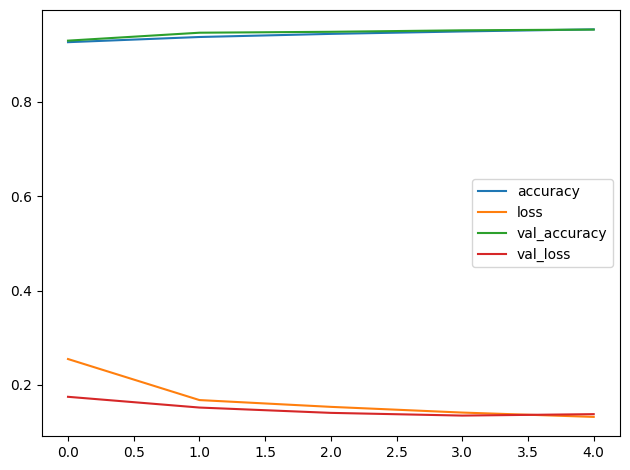

In [65]:
batch_size = 128
epochs = 5

history = model.fit(X_train.values, tf.cast(y_train.values, tf.float32), validation_data=(X_valid.values, tf.cast(y_valid.values, tf.float32)), callbacks=[model_checkpoint_callback], epochs=epochs, batch_size=batch_size)

show_history(history)

In [66]:
# Load the best setup
model.load_weights("best.weights.h5")

# 🔎 Which model is better?
* The one using pre-trained embedding or the one that we've trained from scrath?
* 🔎 Why?

In [67]:
y_pred = model.predict(X_test.values).ravel()
y_pred = [1 if x >= 0.5 else 0 for x in y_pred]
print(f'Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred)}')
print(f'F1 Score: {f1_score(y_true=y_test, y_pred=y_pred)}')

200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
Accuracy: 0.9469732519943689
F1 Score: 0.5568627450980392


# ✅  Tasks for the lecture (2p)
* Try to fine-tune and switch the GloVe embedding and compare the models
    * Fine-tune GloVe 50 embedding - **(1p)**
    * Use GloVe 100 or higher dimentional embbeding - **(1p)**
    * 🔎 Is it any different according to the **F1-Score**?

# 🚀 There is a competition for bonus points this week! 
* Everyone who will send me a correct solution will be included in the F1 - Score toplist
    * 📌 **Send me a link to the notebook, not the .ipynb file (💡 e-mail filter issue)!**
* **Deadline for the competition submission is Sunday 30th at 15:00**
    * The toplist will be publicly available
* There is no limitation in used layers (LSTM, CNN, ...), optimizers and so on
    * 💡 You can use any model architecture from the internet including transfer learning
* The test set is the same as the one that we used in the lecture
    * 💡 It is marked with 🎯 in the notebook
* ⚡ The winner with the best **F1-Score** on test set will be awarded with **10 bonus points**

## 📌 The only limitation is that the model has to be trained/fine-tuned on Colab/Kaggle/Your machine so online sentiment scoring services or REST-API LLMs are forbidden!

![Meme03](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_06_meme_03.png?raw=true)


# ✅ Task solution

The following cells complete all required tasks:
- Fine-tune GloVe 50 embedding
- Use GloVe 100 embedding
- Compare models by F1-Score

In [74]:
import os  # Import os for file existence checks.

results = []  # Create a list that will store final model comparison results.

def evaluate_f1_from_model(model_to_eval, x_data, y_true):  # Define a helper that computes F1 for a trained model.
    y_prob = model_to_eval.predict(x_data.values).ravel()  # Predict probabilities and flatten to 1D.
    y_cls = [1 if x >= 0.5 else 0 for x in y_prob]  # Convert probabilities to binary classes using threshold 0.5.
    score = f1_score(y_true=y_true, y_pred=y_cls)  # Compute F1-score for binary classification.
    return score  # Return computed F1-score.

f1_glove50_frozen = evaluate_f1_from_model(model, X_test, y_test)  # Evaluate the already-trained frozen GloVe 50 model.
results.append({'model': 'GloVe 50 frozen', 'embedding_dim': 50, 'trainable': False, 'f1': f1_glove50_frozen})  # Save frozen GloVe 50 result.
print(f'F1 (GloVe 50 frozen): {f1_glove50_frozen:.6f}')  # Print frozen model F1 to confirm baseline for comparison.

200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
F1 (GloVe 50 frozen): 0.556863


Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.9296 - loss: 0.2290 - val_accuracy: 0.9456 - val_loss: 0.1472
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9514 - loss: 0.1376 - val_accuracy: 0.9554 - val_loss: 0.1238
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9632 - loss: 0.1038 - val_accuracy: 0.9601 - val_loss: 0.1186
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.9713 - loss: 0.0817 - val_accuracy: 0.9617 - val_loss: 0.1258
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.9762 - loss: 0.0666 - val_accuracy: 0.9621 - val_loss: 0.1567
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step
F1 (GloVe 50 fine-tuned): 0.587106


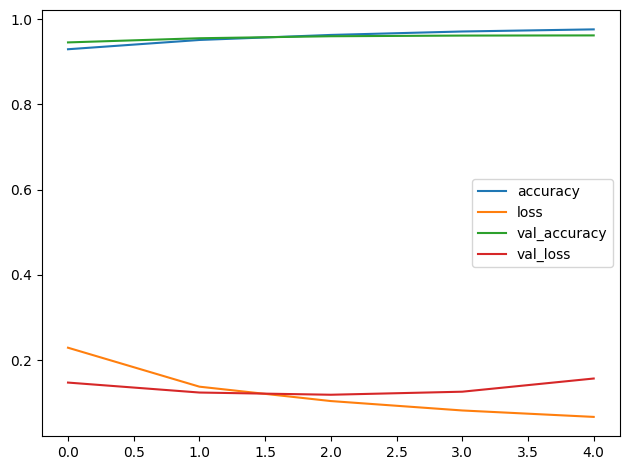

In [75]:
checkpoint_path_50_ft = 'best_glove50_ft.weights.h5'  # Define a dedicated checkpoint file for fine-tuned GloVe 50 model.

input_layer_50_ft = keras.layers.Input(shape=(1,), dtype=tf_string)  # Create text input layer for the model.
x_v_50_ft = vect_layer(input_layer_50_ft)  # Vectorize raw string inputs into integer token sequences.
emb_50_ft = keras.layers.Embedding(  # Create embedding layer initialized by pre-trained GloVe 50 matrix.
    num_tokens,  # Provide vocabulary size including special tokens.
    50,  # Set embedding dimensionality to 50 for GloVe 50.
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),  # Load pre-trained embedding weights.
    trainable=True  # Enable fine-tuning of embedding weights to solve task 1.
)(x_v_50_ft)  # Apply embedding layer to vectorized inputs.
x_50_ft = LSTM(64, activation='relu', return_sequences=True)(emb_50_ft)  # Apply first recurrent layer (LSTM).
x_50_ft = GRU(64, activation='relu', return_sequences=False)(x_50_ft)  # Apply second recurrent layer (GRU).
x_50_ft = keras.layers.Flatten()(x_50_ft)  # Flatten recurrent output before dense layers.
x_50_ft = keras.layers.Dense(64, activation='relu')(x_50_ft)  # Apply first dense layer.
x_50_ft = keras.layers.Dense(32, activation='relu')(x_50_ft)  # Apply second dense layer.
x_50_ft = keras.layers.Dropout(0.2)(x_50_ft)  # Apply dropout regularization.
out_50_ft = keras.layers.Dense(1, activation='sigmoid')(x_50_ft)  # Create sigmoid output for binary sentiment prediction.

model_50_ft = keras.Model(input_layer_50_ft, out_50_ft)  # Build fine-tuned GloVe 50 model.
model_50_ft.compile(  # Compile model with the same optimizer/loss setup for fair comparison.
    optimizer=keras.optimizers.AdamW(),  # Use AdamW optimizer.
    loss=keras.losses.BinaryCrossentropy(),  # Use binary cross-entropy loss.
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]  # Track binary accuracy during training.
)  # Finish model compilation.

checkpoint_50_ft = tf.keras.callbacks.ModelCheckpoint(  # Create callback to keep best validation-loss weights.
    filepath=checkpoint_path_50_ft,  # Save best weights into dedicated checkpoint path.
    save_weights_only=True,  # Save only model weights.
    monitor='val_loss',  # Monitor validation loss.
    mode='auto',  # Auto mode for minimizing monitored metric.
    save_best_only=True  # Keep only the best checkpoint.
)  # Finish checkpoint callback configuration.

history_50_ft = model_50_ft.fit(  # Train fine-tuned GloVe 50 model.
    X_train.values,  # Pass training text samples.
    tf.cast(y_train.values, tf.float32),  # Pass training labels cast to float.
    validation_data=(X_valid.values, tf.cast(y_valid.values, tf.float32)),  # Pass validation data.
    callbacks=[checkpoint_50_ft],  # Use checkpoint callback.
    epochs=5,  # Train for 5 epochs as requested.
    batch_size=128  # Use batch size 128 to match previous setup.
)  # Finish model training.

show_history(history_50_ft)  # Plot training history for quick visual check.
model_50_ft.load_weights(checkpoint_path_50_ft)  # Restore best validation-loss weights.
f1_glove50_finetuned = evaluate_f1_from_model(model_50_ft, X_test, y_test)  # Evaluate F1-score on test split.
results.append({'model': 'GloVe 50 fine-tuned', 'embedding_dim': 50, 'trainable': True, 'f1': f1_glove50_finetuned})  # Save fine-tuned model result.
print(f'F1 (GloVe 50 fine-tuned): {f1_glove50_finetuned:.6f}')  # Print F1 for fine-tuned GloVe 50 model.

Found 400000 word vectors in 100d file.
Converted 8504 words (1496 misses) for 100d matrix.
Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.9277 - loss: 0.2382 - val_accuracy: 0.9304 - val_loss: 0.1619
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9411 - loss: 0.1652 - val_accuracy: 0.9468 - val_loss: 0.1433
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9488 - loss: 0.1476 - val_accuracy: 0.9519 - val_loss: 0.1327
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9538 - loss: 0.1340 - val_accuracy: 0.9542 - val_loss: 0.1270
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9568 - loss: 0.1258 - val_accuracy: 0.9550 - val_loss: 0.1281
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
F1 (GloVe 100 frozen): 0.581132


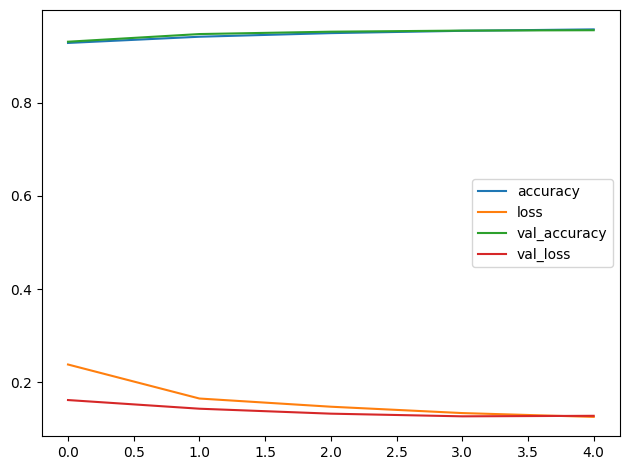

In [76]:
if not os.path.exists('glove.6B.100d.txt'):  # Check if GloVe 100d file is already present.
    if not os.path.exists('glove.6B.zip'):  # Check if GloVe zip archive is already present.
        get_ipython().system('wget http://nlp.stanford.edu/data/glove.6B.zip')  # Download archive only when missing.
    get_ipython().system('unzip -q -o glove.6B.zip glove.6B.100d.txt')  # Extract only 100d embedding file.

path_to_glove_100_file = 'glove.6B.100d.txt'  # Define path to GloVe 100d text file.
embeddings_index_100 = {}  # Create dictionary for 100d word embeddings.
with open(path_to_glove_100_file) as f:  # Open 100d embedding file for reading.
    for line in f:  # Iterate through all embedding lines.
        word, coefs = line.split(maxsplit=1)  # Split each line into word and vector values.
        coefs = np.fromstring(coefs, 'f', sep=' ')  # Convert vector string to float NumPy array.
        embeddings_index_100[word] = coefs  # Save word vector to dictionary.
print(f'Found {len(embeddings_index_100)} word vectors in 100d file.')  # Print total loaded vectors for validation.

embedding_dim_100 = 100  # Set embedding dimension for GloVe 100 model.
num_tokens_100 = len(voc) + 2  # Set number of tokens according to existing vocabulary.
embedding_matrix_100 = np.zeros((num_tokens_100, embedding_dim_100))  # Allocate zero matrix for 100d embeddings.
hits_100 = 0  # Initialize counter for matched words.
misses_100 = 0  # Initialize counter for missing words.
for word, i in word_index.items():  # Iterate over vectorizer vocabulary mapping.
    embedding_vector = embeddings_index_100.get(word)  # Get pre-trained vector for current word.
    if embedding_vector is not None:  # Check whether vector exists in GloVe 100 dictionary.
        embedding_matrix_100[i] = embedding_vector  # Assign vector into embedding matrix row.
        hits_100 += 1  # Increase hit counter.
    else:  # Handle words not present in GloVe dictionary.
        misses_100 += 1  # Increase miss counter.
print(f'Converted {hits_100} words ({misses_100} misses) for 100d matrix.')  # Print matrix coverage summary.

checkpoint_path_100 = 'best_glove100_frozen.weights.h5'  # Define dedicated checkpoint path for GloVe 100 model.

input_layer_100 = keras.layers.Input(shape=(1,), dtype=tf_string)  # Create input layer for GloVe 100 model.
x_v_100 = vect_layer(input_layer_100)  # Vectorize input text with the existing text vectorizer.
emb_100 = keras.layers.Embedding(  # Create embedding layer initialized from GloVe 100 matrix.
    num_tokens_100,  # Set token count for embedding layer.
    embedding_dim_100,  # Set embedding dimension to 100.
    embeddings_initializer=keras.initializers.Constant(embedding_matrix_100),  # Use precomputed 100d matrix.
    trainable=False  # Keep embeddings frozen to isolate dimensionality effect simply.
)(x_v_100)  # Apply embedding layer to vectorized inputs.
x_100 = LSTM(64, activation='relu', return_sequences=True)(emb_100)  # Apply LSTM layer.
x_100 = GRU(64, activation='relu', return_sequences=False)(x_100)  # Apply GRU layer.
x_100 = keras.layers.Flatten()(x_100)  # Flatten recurrent features.
x_100 = keras.layers.Dense(64, activation='relu')(x_100)  # Apply first dense layer.
x_100 = keras.layers.Dense(32, activation='relu')(x_100)  # Apply second dense layer.
x_100 = keras.layers.Dropout(0.2)(x_100)  # Apply dropout regularization.
out_100 = keras.layers.Dense(1, activation='sigmoid')(x_100)  # Create binary output layer.

model_100 = keras.Model(input_layer_100, out_100)  # Build GloVe 100 model instance.
model_100.compile(  # Compile GloVe 100 model.
    optimizer=keras.optimizers.AdamW(),  # Use AdamW optimizer.
    loss=keras.losses.BinaryCrossentropy(),  # Use binary cross-entropy loss.
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]  # Track binary accuracy metric.
)  # Finish compile configuration.

checkpoint_100 = tf.keras.callbacks.ModelCheckpoint(  # Configure checkpoint callback for GloVe 100 model.
    filepath=checkpoint_path_100,  # Set path where best weights will be stored.
    save_weights_only=True,  # Save only weights.
    monitor='val_loss',  # Track validation loss.
    mode='auto',  # Let Keras infer optimization direction.
    save_best_only=True  # Keep only best validation-loss checkpoint.
)  # Finish callback configuration.

history_100 = model_100.fit(  # Train GloVe 100 model on training split.
    X_train.values,  # Provide training text samples.
    tf.cast(y_train.values, tf.float32),  # Provide training labels as float.
    validation_data=(X_valid.values, tf.cast(y_valid.values, tf.float32)),  # Provide validation split.
    callbacks=[checkpoint_100],  # Use checkpoint callback during training.
    epochs=5,  # Train for 5 epochs as requested.
    batch_size=128  # Use batch size 128.
)  # Finish model training.

show_history(history_100)  # Plot GloVe 100 training history.
model_100.load_weights(checkpoint_path_100)  # Restore best validation-loss checkpoint.
f1_glove100_frozen = evaluate_f1_from_model(model_100, X_test, y_test)  # Compute test F1-score for GloVe 100 model.
results.append({'model': 'GloVe 100 frozen', 'embedding_dim': 100, 'trainable': False, 'f1': f1_glove100_frozen})  # Save GloVe 100 result.
print(f'F1 (GloVe 100 frozen): {f1_glove100_frozen:.6f}')  # Print GloVe 100 F1-score.

In [77]:
results_df = pd.DataFrame(results)  # Convert collected result dictionaries to a DataFrame.
results_df = results_df.sort_values(by='f1', ascending=False).reset_index(drop=True)  # Sort models by F1-score descending.
print(results_df)  # Print final model comparison table.

best_row = results_df.iloc[0]  # Read top-performing model row.
print(f"Best model by F1: {best_row['model']} (F1={best_row['f1']:.6f})")  # Print simple winner summary.

                 model  embedding_dim  trainable        f1
0  GloVe 50 fine-tuned             50       True  0.587106
1     GloVe 100 frozen            100      False  0.581132
2      GloVe 50 frozen             50      False  0.556863
Best model by F1: GloVe 50 fine-tuned (F1=0.587106)
